# Lecture

## Problems in sequence processing

<table>
    <th>Problem</th>
    <th>Input</th>
    <th>Output</th>
    <th>Relation</th>
    <th>Mathematical formulation</th>
    <tr>
        <td>Next word prediction</td>
        <td>Text</td>
        <td>Next word</td>
        <td>Many-to-one</td>
        <td>
            \begin{aligned}
            p(y_t | y_{t-1}, y_{t-2}, \ldots, y_1)
            \end{aligned}
        </td>
    </tr>
    <tr>
        <td>Sentiment classification</td>
        <td>Text</td>
        <td>Label</td>
        <td>Many-to-one</td>
        <td>
            \begin{aligned}
            p(c | y_t, y_{t-1}, \ldots, y_1)
            \end{aligned}
        </td>
    </tr>
    <tr>
        <td>Machine translation</td>
        <td>Text in one language</td>
        <td>Text in other language</td>
        <td>Many-to-many</td>
        <td>
            \begin{aligned}
            p(y_t, y_{t-1}, \ldots, y_1 | x_t, x_{t-1}, \ldots, x_1)
            \end{aligned}
        </td>
    </tr>
</table>

## Representations vs features

- Feature vector is a representation
- Representations are usually not interpretable
- Representations capture hidden structure, more than we can describe with features

## Representations vs features

Consider next word prediction:
> The most complicated and difficult part of it was only just **beginning**

<table>
    <tr>
        <td>Idea 1: use previous word (or words)</td>
        <td>Feature representation: [0, 0, 0, 1, 0, 0]</td>
    </tr>
    <tr>
        <td>Problem 1: long-range dependencies</td>
        <td>France is where I grew up, but I now live in Boston. I speak fluent ____</td>
    </tr>
</table>

<table>
    <tr>
        <td>Idea 2: use bag-of-words (TF-IDF)</td>
        <td>Feature representation: [0, 0, 2, 0, 3, 0]</td>
    </tr>
    <tr>
        <td>Problem 2: order is not preserved</td>
        <td>The food was good, not bad at all<br>vs<br>The food was bad, not good at all</td>
    </tr>
</table>

## Sequence processing models requirements

- Processes variable-length sequences
- Captures long-term dependencies
- Retain order information
- Natural preprocessing

## Sequence processing models: classic ML

<table>
    <tr>
        <td>Processes variable-length sequences</td>
        <td>Limited</td>
    </tr>
    <tr>
        <td>Captures long-term dependencies</td>
        <td>No</td>
    </tr>
    <tr>
        <td>Retain order information</td>
        <td>No</td>
    </tr>
    <tr>
        <td>Natural preprocessing</td>
        <td>kinda</td>
    </tr>
</table>

## Sequence processing models: classic FCNN

<table>
    <tr>
        <td>Processes variable-length sequences</td>
        <td>Limited</td>
    </tr>
    <tr>
        <td>Captures long-term dependencies</td>
        <td>Limited</td>
    </tr>
    <tr>
        <td>Retain order information</td>
        <td>Limited</td>
    </tr>
    <tr>
        <td>Natural preprocessing</td>
        <td>kinda</td>
    </tr>
</table>

## Solution: Recurrent Neural Network

<img src="rnn.png" width=800px/>

$$
\begin{aligned}
h_t & = f_h(h_{t-1}, x_t), \
\hat{y}_t = f_y(h_t)
\end{aligned}
$$

$$
p(y_t | y_{t-1}, y_{t-2}, \ldots, y_1, x_t, x_{t-1}, x_{t-2}, \ldots, x_1) = p(y_t | h_{t-1}, x_t) = p(y_t | h_t) 
$$

## Vanilla RNN

<img src="rnn.png" width=800px/>

$$
\begin{aligned}
h_t & = \tanh (Vx_t + Wh_{t-1} + b_h), \\
\hat{y}_t & = \operatorname{softmax} (Uh_t + b_h)
\end{aligned}
$$

## Sequence to sequence model

<img src="seq2seq.png" width=800px/>

## Problems with RNN: long inference

<img src="rnn-inference.png" width=400px/>

Processing time is $O(T)$

## Problems with RNN: gradients

$$
\begin{aligned}
h_t & = \tanh (Vx_t + Wh_{t-1} + b_h), \\
\hat{y}_t & = \operatorname{softmax} (Uh_t + b_h)
\end{aligned}
$$

$$
\frac{\partial L_t}{\partial W} = \frac{\partial L_t}{\partial \hat{y}_t} \frac{\partial \hat{y}_t}{\partial W}
$$

$$
\frac{\partial L_t}{\partial \hat{y}^t} \frac{\partial \hat{y}^t}{\partial W}=\frac{\partial L_t}{\partial \hat{y}^t} \frac{\partial \hat{y}^t}{\partial h^t}\left(\frac{\partial h^t}{\partial W}+\frac{\partial h^t}{\partial h^{t-1}} \frac{\partial h^{t-1}}{\partial W}+\cdots\right)
$$

$$
\frac{\partial L_t}{\partial \hat{y}^t} \frac{\partial \hat{y}^t}{\partial W}=\frac{\partial L_t}{\partial \hat{y}^t} \frac{\partial \hat{y}^t}{\partial h^t} \sum_{i=0}^t \frac{\partial h^i}{\partial W}\left(\prod_{j=i+1}^t \frac{\partial h^j}{\partial h^{j-1}}\right)
$$

## Problems with RNN: exploding gradients

$$
\frac{\partial L_t}{\partial W} = \frac{\partial L_t}{\partial \hat{y}^t} \frac{\partial \hat{y}^t}{\partial h^t} \sum_{i=0}^t \frac{\partial h^i}{\partial W}\left(\prod_{j=i+1}^t \frac{\partial h^j}{\partial h^{j-1}}\right)
$$

If $\| \frac{\partial h^j}{\partial h^{j-1}} \| > 1$, then non-stationary. Gradients can "explode" and become nans. Solutions:
- Gradient clipping
- BPTT

## Problems with RNN: vanishing gradients

$$
\frac{\partial L_t}{\partial W} = \frac{\partial L_t}{\partial \hat{y}^t} \frac{\partial \hat{y}^t}{\partial h^t} \sum_{i=0}^t \frac{\partial h^i}{\partial W}\left(\prod_{j=i+1}^t \frac{\partial h^j}{\partial h^{j-1}}\right)
$$

If $\| \frac{\partial h^j}{\partial h^{j-1}} \| < 1$, then gradients quickly decay to zero with $t$, can't learn long-range dependencies. Solutions:
- Use ReLU
- Clever initialization of parameters

Because of this, vanilla RNNs have a fundamental problem of quick forgetting.

## Solution: gated architectures

<img src="gated.png" width=800px/>

## LSTM

<img src="lstm.png" width=800px/>

The key to LSTMs is the introduction of cell state. Temporal representation now consists not only of hidden state (capturing short-term dependencies), but also of the cell state, capturing long-range dependencies. LSTM has the ability to change the cell state with the information from hidden state, regulated by three gates, forget gate, input gate and output gate.

## LSTM: forget gate

<img src="lstm-f.png" width=800px/>

## LSTM: input gate

<img src="lstm-i.png" width=800px/>

## LSTM: cell state update

<img src="lstm-c.png" width=800px/>

## LSTM: hidden state update

<img src="lstm-o.png" width=800px/>

## GRU

<table>
    <tr>
        <td><img src="gru.png", width=300px/></td>
        <td>
        \begin{aligned}
        z_t & =\sigma\left(W_z \cdot\left[h_{t-1}, x_t\right]\right) \\
        r_t & =\sigma\left(W_r \cdot\left[h_{t-1}, x_t\right]\right) \\
        \tilde{h}_t & =\tanh \left(W \cdot\left[r_t * h_{t-1}, x_t\right]\right) \\
        h_t & =\left(1-z_t\right) * h_{t-1}+z_t * \tilde{h}_t
        \end{aligned}
        </td>
    </tr>
</table>

There is no cell state in GRU, and there are only two gates: update and reset. It is computationally simpler but very close in terms of results.

## Multilayer LSTM

<table>
    <tr>
        <td><img src="multilayer-lstm.png" width=300px/></td>
        <td><img src="mult-lstm-perf.png" width=700px/></td>
    </tr>
</table>

## Bidirectional LSTM

<table>
    <tr>
        <td><img src="bidir-lstm.png" width=400px/></td>
        <td>Bidirectional LSTM are useful when we benefit from the future data or can use it<br>
            • Handwriting Recognition<br>
            • Speech Recognition<br>s
            • Protein Structure Prediction (Bioinformatics)<br>
        </td>
    </tr>
</table>

## Problems with LSTM

<img src="seq2seq.png" width=700px/>

- The bottleneck for the representation
- Goes from past to future
- Long time to train, no improvement with GPU
- Tend to focus on the end of the sequence

# Webinar

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm.notebook import tqdm

In [2]:
df = pd.read_csv('PJME_hourly.csv')

In [3]:
df = df.set_index(["Datetime"]).rename(columns={'PJME_MW': 'value'})
df.index = pd.to_datetime(df.index)
df = df.sort_index()

In [4]:
df.head()

,value
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [5]:
df.tail()

,value
Datetime,
2018-08-02 20:00:00,44057.0
2018-08-02 21:00:00,43256.0
2018-08-02 22:00:00,41552.0
2018-08-02 23:00:00,38500.0
2018-08-03 00:00:00,35486.0


<Axes: xlabel='Datetime'>

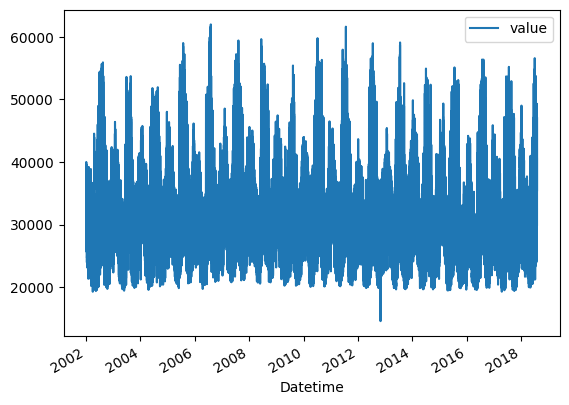

In [6]:
df.plot()

In [7]:
for k in range(1, 101):
    df[f"lag_{k}"] = df["value"].shift(k)
df = df.copy()

/var/folders/33/j0cl7y453td68qb96j7bqcj4cf41kc/T/ipykernel_7917/2245740435.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"lag_{k}"] = df["value"].shift(k)


In [8]:
df.head()

,value,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,...,lag_91,lag_92,lag_93,lag_94,lag_95,lag_96,lag_97,lag_98,lag_99,lag_100
Datetime,,,,,,,,,,,,,,,,,,,,,
2002-01-01 01:00:00,30393.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,30393.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 03:00:00,28357.0,29265.0,30393.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 04:00:00,27899.0,28357.0,29265.0,30393.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2002-01-01 05:00:00,28057.0,27899.0,28357.0,29265.0,30393.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df = df.iloc[100:]

In [15]:
df["hour"] = df.index.hour
df["day"] = df.index.day
df["month"] = df.index.month
df["day_of_week"] = df.index.dayofweek

In [16]:
for col, st, freq in zip(
    ["hour", "day", "month", "day_of_week"],
    [0, 0, 1, 0],
    [24, 365, 12, 7],
):
    df[f"sin_{col}"] = df[col].transform(lambda x: np.sin(2 * np.pi * (x - st)  / freq))
    df[f"cos_{col}"] = df[col].transform(lambda x: np.cos(2 * np.pi * (x - st)  / freq))

In [17]:
df

,value,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,...,month,day_of_week,sin_hour,cos_hour,sin_day,cos_day,sin_month,cos_month,sin_day_of_week,cos_day_of_week
Datetime,,,,,,,,,,,,,,,,,,,,,
2002-01-05 05:00:00,26822.0,26669.0,27034.0,27501.0,28635.0,30924.0,33202.0,35368.0,36762.0,37539.0,...,1,5,0.965926,2.588190e-01,0.085965,0.996298,0.0,1.000000,-0.974928,-0.222521
2002-01-05 06:00:00,27399.0,26822.0,26669.0,27034.0,27501.0,28635.0,30924.0,33202.0,35368.0,36762.0,...,1,5,1.000000,6.123234e-17,0.085965,0.996298,0.0,1.000000,-0.974928,-0.222521
2002-01-05 07:00:00,28557.0,27399.0,26822.0,26669.0,27034.0,27501.0,28635.0,30924.0,33202.0,35368.0,...,1,5,0.965926,-2.588190e-01,0.085965,0.996298,0.0,1.000000,-0.974928,-0.222521
2002-01-05 08:00:00,29709.0,28557.0,27399.0,26822.0,26669.0,27034.0,27501.0,28635.0,30924.0,33202.0,...,1,5,0.866025,-5.000000e-01,0.085965,0.996298,0.0,1.000000,-0.974928,-0.222521
2002-01-05 09:00:00,31241.0,29709.0,28557.0,27399.0,26822.0,26669.0,27034.0,27501.0,28635.0,30924.0,...,1,5,0.707107,-7.071068e-01,0.085965,0.996298,0.0,1.000000,-0.974928,-0.222521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-08-02 20:00:00,44057.0,45641.0,46760.0,46816.0,46989.0,47154.0,46534.0,45372.0,43954.0,42189.0,...,8,3,-0.866025,5.000000e-01,0.034422,0.999407,-0.5,-0.866025,0.433884,-0.900969
2018-08-02 21:00:00,43256.0,44057.0,45641.0,46760.0,46816.0,46989.0,47154.0,46534.0,45372.0,43954.0,...,8,3,-0.707107,7.071068e-01,0.034422,0.999407,-0.5,-0.866025,0.433884,-0.900969
2018-08-02 22:00:00,41552.0,43256.0,44057.0,45641.0,46760.0,46816.0,46989.0,47154.0,46534.0,45372.0,...,8,3,-0.500000,8.660254e-01,0.034422,0.999407,-0.5,-0.866025,0.433884,-0.900969


<Axes: xlabel='Datetime'>

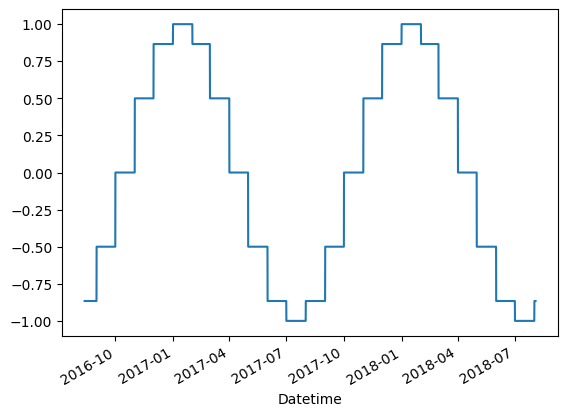

In [20]:
df.iloc[-24 * 30 * 24:]["cos_month"].plot()

In [21]:
import holidays

In [22]:
us_holidays = holidays.US()

In [23]:
df["is_holiday"] = df.index.to_series().transform(lambda x: int(x.replace(hour = 0) in us_holidays))

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
df.to_parquet("features.parquet")

In [26]:
X, y = df.drop("value", axis=1), df[["value"]]

In [27]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
X_train.head()

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,day_of_week,sin_hour,cos_hour,sin_day,cos_day,sin_month,cos_month,sin_day_of_week,cos_day_of_week,is_holiday
Datetime,,,,,,,,,,,,,,,,,,,,,
2002-01-05 05:00:00,26669.0,27034.0,27501.0,28635.0,30924.0,33202.0,35368.0,36762.0,37539.0,38263.0,...,5,0.965926,2.588190e-01,0.085965,0.996298,0.0,1.0,-0.974928,-0.222521,0
2002-01-05 06:00:00,26822.0,26669.0,27034.0,27501.0,28635.0,30924.0,33202.0,35368.0,36762.0,37539.0,...,5,1.000000,6.123234e-17,0.085965,0.996298,0.0,1.0,-0.974928,-0.222521,0
2002-01-05 07:00:00,27399.0,26822.0,26669.0,27034.0,27501.0,28635.0,30924.0,33202.0,35368.0,36762.0,...,5,0.965926,-2.588190e-01,0.085965,0.996298,0.0,1.0,-0.974928,-0.222521,0
2002-01-05 08:00:00,28557.0,27399.0,26822.0,26669.0,27034.0,27501.0,28635.0,30924.0,33202.0,35368.0,...,5,0.866025,-5.000000e-01,0.085965,0.996298,0.0,1.0,-0.974928,-0.222521,0
2002-01-05 09:00:00,29709.0,28557.0,27399.0,26822.0,26669.0,27034.0,27501.0,28635.0,30924.0,33202.0,...,5,0.707107,-7.071068e-01,0.085965,0.996298,0.0,1.0,-0.974928,-0.222521,0


In [30]:
xscaler = StandardScaler()
X_train = xscaler.fit_transform(X_train)
X_val = xscaler.transform(X_val)

yscaler = StandardScaler()
y_train = yscaler.fit_transform(y_train)
y_val = yscaler.transform(y_val)

In [33]:
X_train[:5, :5]

array([[-0.8792073 , -0.8224797 , -0.74990436, -0.5736884 , -0.2180048 ],
       [-0.85543237, -0.87919751, -0.8224719 , -0.74990147, -0.5736951 ],
       [-0.76577137, -0.85542265, -0.87918956, -0.82246893, -0.74990864],
       [-0.58582779, -0.7657619 , -0.85541476, -0.87918654, -0.82247629],
       [-0.40681657, -0.58581885, -0.76575423, -0.85541176, -0.87919405]])

In [34]:
from torch.utils.data import TensorDataset, DataLoader, Dataset

class SeqDataset(Dataset):
    def __init__(self, tensor, y, length):
        super().__init__()
        self.l = len(tensor)

        self.tensor = torch.cat((
            torch.zeros((length + 1, tensor.shape[1])),
            tensor
        ))
        self.y = torch.cat((
            torch.zeros((length + 1, y.shape[1])),
            y
        ), )
        self.length = length

    def __len__(self):
        return self.l

    def __getitem__(self, idx):
        x = self.tensor[idx: idx + self.length]
        y = self.y[idx + self.length]
        return x, y

In [35]:
bs = 64

In [36]:
X_train = torch.Tensor(X_train)
X_val = torch.Tensor(X_val)
y_train = torch.Tensor(y_train)
y_val = torch.Tensor(y_val)

In [37]:
ds_train = SeqDataset(X_train, y_train, 10)
ds_val = SeqDataset(X_val, y_val, 10)

In [38]:
dl_train = DataLoader(ds_train, batch_size=bs, shuffle=False, drop_last=True)
dl_val = DataLoader(ds_val, batch_size=bs, shuffle=False, drop_last=True)

In [39]:
class MyModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim, dropout_p):
        super(MyModel, self).__init__()

        self.hidden_dim = hidden_dim

        self.rnn = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout_p
        )

        self.fc = nn.Linear(in_features=hidden_dim, out_features=output_dim)

    def forward(self, x):
        out, (hn, cn) = self.rnn(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

In [40]:
X_train.shape

torch.Size([116212, 113])

In [42]:
y_train.shape

torch.Size([116212, 1])

In [43]:
model = MyModel(
    input_dim=113,
    hidden_dim=64,
    output_dim=1,
    num_layers=3,
    dropout_p=0.1
)

In [44]:
import torch.optim as optim

In [45]:
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)

/Users/nstulov/miniconda3/envs/msai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [46]:
lossf = nn.MSELoss()

In [47]:
from tqdm.auto import tqdm

In [48]:
for epoch in range(10):
    model.train()

    losses = []
    for batch, y in dl_train:
        loss_value = lossf(model(batch), y)
        loss_value.backward()

        optimizer.step()
        optimizer.zero_grad()

        losses.append(loss_value.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for batch, y in dl_val:
            loss_value = lossf(model(batch), y)
            val_losses.append(loss_value.item())


    print(
        f"[{epoch}/10] Training loss: {np.mean(losses):.4f}\t Validation loss: {np.mean(val_losses):.4f}"
    )

[0/10] Training loss: 0.0991	 Validation loss: 0.1194
[1/10] Training loss: 0.0271	 Validation loss: 0.0349
[2/10] Training loss: 0.0199	 Validation loss: 0.0294
[3/10] Training loss: 0.0155	 Validation loss: 0.0239
[4/10] Training loss: 0.0133	 Validation loss: 0.0166
[5/10] Training loss: 0.0126	 Validation loss: 0.0125
[6/10] Training loss: 0.0120	 Validation loss: 0.0144
[7/10] Training loss: 0.0106	 Validation loss: 0.0122
[8/10] Training loss: 0.0103	 Validation loss: 0.0112
[9/10] Training loss: 0.0101	 Validation loss: 0.0104


In [49]:
model.eval()
outputs = []
true_vals = []
with torch.no_grad():
    for batch, y in dl_val:
        out = model(batch)
        outputs.append(out.squeeze().numpy())
        true_vals.append(y.squeeze().numpy())

In [54]:
outputs = np.concatenate(outputs, axis=0)

In [56]:
true_vals = np.concatenate(true_vals, axis=0)

In [59]:
true_vals.shape

(28992,)

In [58]:
y_val.shape

torch.Size([29054, 1])

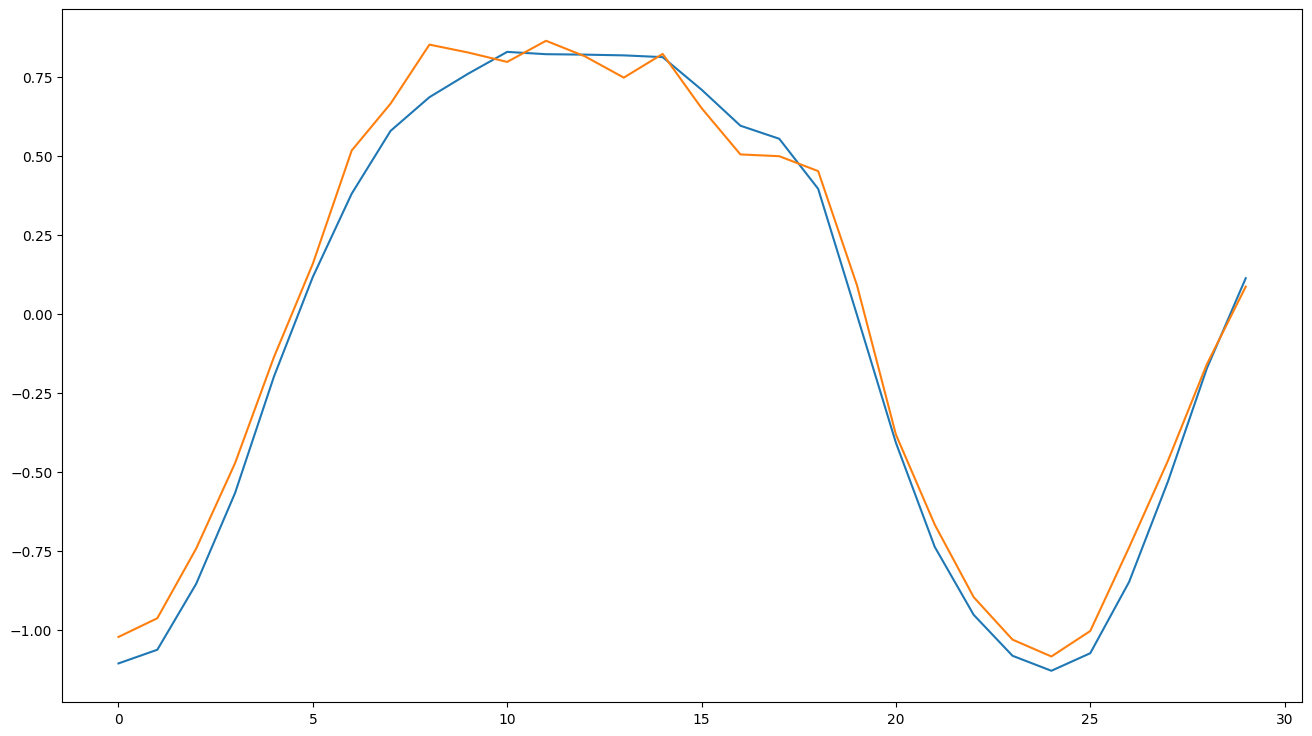

In [63]:
fig, ax = plt.subplots(figsize=(16,9))
ax.plot(true_vals[-30:], label="ground truth")
ax.plot(outputs[-30:], label="predictions")

In [64]:
from sklearn.metrics import mean_squared_error

In [66]:
mean_squared_error(true_vals, outputs)

0.010381246

In [67]:
np.random.randint(len(ds_val))

8430

In [68]:
ds_val[8430]

(tensor([[-1.7399, -1.7940, -1.7856,  ..., -1.3791, -0.3147, -0.1763],
         [-1.6038, -1.7399, -1.7940,  ..., -1.3791, -0.3147, -0.1763],
         [-1.4047, -1.6038, -1.7399,  ..., -1.3791, -0.3147, -0.1763],
         ...,
         [-1.0949, -1.0155, -0.9706,  ..., -1.3791, -0.3147, -0.1763],
         [-1.1962, -1.0949, -1.0155,  ..., -1.3791, -0.3147, -0.1763],
         [-1.3019, -1.1962, -1.0949,  ..., -1.3791, -0.3147, -0.1763]]),
 tensor([-1.3939]))

In [70]:
xx, yy = ds_val[8430]

In [71]:
xx.shape

torch.Size([10, 113])

In [72]:
xx = xx.clone()
xx.requires_grad = True
yy = yy.clone()

zz = model(xx.unsqueeze(0))

In [73]:
zz.shape

torch.Size([1, 1])

In [74]:
loss_value = lossf(zz, yy.unsqueeze(0))

loss_value.backward()
gradients = xx.grad

gradients.shape

torch.Size([10, 113])

In [75]:
loss_value.shape

torch.Size([])

In [76]:
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.5)
sns.despine()

<Figure size 640x480 with 0 Axes>

In [83]:
from matplotlib.colors import SymLogNorm

<Axes: >

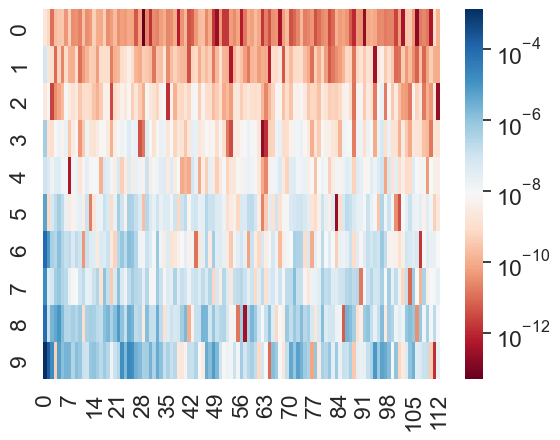

In [87]:
sns.heatmap((gradients ** 2).numpy(), cmap="RdBu", norm=LogNorm())